# Model Training - Gradient Boosting Classifier Model


In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
from scipy.stats import randint, uniform

import joblib

In [48]:
RANDOM_STATE = 42
target_col = 'Depression'

In [49]:
df = pd.read_csv("preprocessed_student_depression(GBC-model).csv")
print(df.shape)
df.head()

(27867, 14)


,Gender,Age,Academic_Pressure,CGPA,Study_Satisfaction,Sleep_Duration,Dietary_Habits,Degree,Suicidal Thoughts,Study_Hours,Financial_Stress,Mental Illness History,Depression,Age_Group
0,Male,33.0,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,Adult
1,Female,24.0,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0,Young Adult
2,Male,31.0,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0,Adult
3,Female,28.0,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1,Adult
4,Female,25.0,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0,Young Adult


## Data Split

In [50]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

((22293, 13), (5574, 13))

### Preprocessing after splitting 

In [51]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

Scaling Numerical Feature

In [52]:
cols_to_scale = [col for col in numerical_cols if col != "Depression"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_scaled[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test_scaled[cols_to_scale])


One-Hot Encoding

In [53]:
encoder = OneHotEncoder(handle_unknown='ignore', drop='first')

X_train_cat = encoder.fit_transform(X_train_scaled[categorical_cols])
X_test_cat = encoder.transform(X_test_scaled[categorical_cols])

# Convert to DataFrame
encoded_col_names = encoder.get_feature_names_out(categorical_cols)
X_train_cat_df = pd.DataFrame(X_train_cat.toarray(), columns=encoded_col_names, index=X_train_scaled.index)
X_test_cat_df  = pd.DataFrame(X_test_cat.toarray(),  columns=encoded_col_names, index=X_test_scaled.index)


In [54]:
X_train_final = pd.concat([X_train_scaled[cols_to_scale], X_train_cat_df], axis=1)
X_test_final  = pd.concat([X_test_scaled[cols_to_scale],  X_test_cat_df], axis=1)

print(X_train_final.shape, X_test_final.shape)
X_train_final.head()

(22293, 46) (5574, 46)


,Age,Academic_Pressure,CGPA,Study_Satisfaction,Study_Hours,Financial_Stress,Gender_Male,Sleep_Duration_7-8 hours,Sleep_Duration_Less than 5 hours,Sleep_Duration_More than 8 hours,...,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Suicidal Thoughts_Yes,Mental Illness History_Yes,Age_Group_Senior,Age_Group_Teen,Age_Group_Young Adult
23520,-1.593144,-0.106099,1.313302,0.044423,-0.310536,0.597211,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
11964,1.252686,0.619000,0.151772,1.517036,0.766855,1.293167,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
10142,0.033045,-0.831199,0.043091,0.780730,-0.579883,-1.490656,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
24567,1.455960,0.619000,-1.233912,0.044423,-0.849231,-0.794700,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3175,-0.373503,-1.556299,0.362342,-0.691883,1.036202,1.293167,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


### Check Data Leakage

In [55]:
# how many row indices appear in BOTH train and test?
overlap = set(X_train_final.index).intersection(set(X_test_final.index))
print(len(overlap))


0


## Initialize and Train the Gradient Boosting Classifier Model

In [56]:
gbc_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3, # common value for max_depth
    min_samples_leaf=1, # common value for min_samples_leaf
    subsample=0.7, # common value for subsample
    random_state=RANDOM_STATE
)

gbc_model.fit(X_train_final, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42, subsample=0.7)

## Evaluations

### Predictions on Test Data

In [57]:
y_pred = gbc_model.predict(X_test_final)
y_proba = gbc_model.predict_proba(X_test_final)[:, 1]

### Confusion Matrix

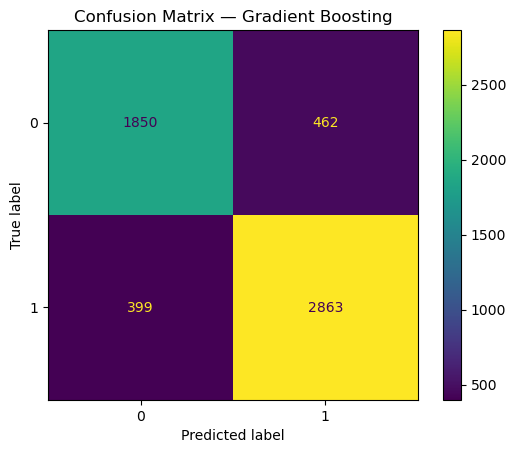

In [58]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix — Gradient Boosting")
plt.show()

### Metrics Calculations

In [59]:
# Metrics calculation
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.8455
Precision: 0.8611
Recall: 0.8777
F1-Score: 0.8693
ROC-AUC: 0.9219

Classification Report:

              precision    recall  f1-score   support

           0     0.8226    0.8002    0.8112      2312
           1     0.8611    0.8777    0.8693      3262

    accuracy                         0.8455      5574
   macro avg     0.8418    0.8389    0.8403      5574
weighted avg     0.8451    0.8455    0.8452      5574



### ROC Curve

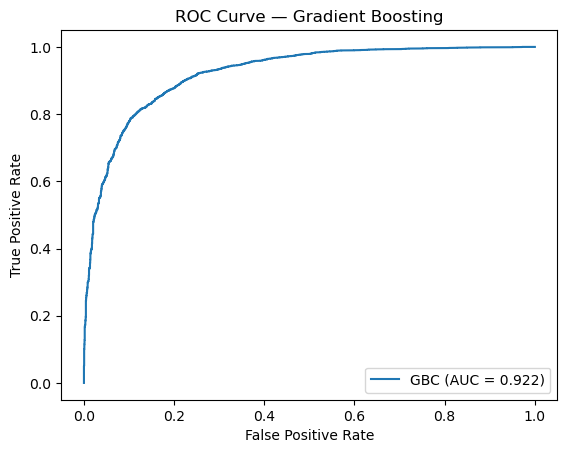

In [60]:
fp_rate, tp_rate, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fp_rate, tp_rate, label=f'GBC (AUC = {roc_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Gradient Boosting')
plt.legend()
plt.show()

## Cross Validation

In [61]:
X_final = pd.concat([X_train_final, X_test_final])
y_final = pd.concat([y_train, y_test])

s_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(gbc_model, X_final, y_final, cv=s_k_fold, scoring="accuracy")
cv_f1  = cross_val_score(gbc_model, X_final, y_final, cv=s_k_fold, scoring="f1")
cv_auc = cross_val_score(gbc_model, X_final, y_final, cv=s_k_fold, scoring="roc_auc")

print("Cross-Validation Accuracy:  mean={:.4f}, std={:.4f}".format(cv_acc.mean(), cv_acc.std()))
print("Cross-Validation F1:        mean={:.4f}, std={:.4f}".format(cv_f1.mean(),  cv_f1.std()))
print("Cross-Validation ROC-AUC:   mean={:.4f}, std={:.4f}".format(cv_auc.mean(), cv_auc.std()))

Cross-Validation Accuracy:  mean=0.8476, std=0.0041
Cross-Validation F1:        mean=0.8719, std=0.0036
Cross-Validation ROC-AUC:   mean=0.9215, std=0.0034


## Hyperparameter Tuning

### Pipeline (Imputer + Gradinet Boosting Classifier)

In [62]:
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("gbc", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

### Grid & Search

In [63]:
param_grid = {
    "gbc__n_estimators": [200, 300, 400, 500],
    "gbc__learning_rate": [0.05, 0.08, 0.1],
    "gbc__max_depth": [2, 3, 4],
    "gbc__min_samples_leaf": [1, 3, 5],
    "gbc__subsample": [0.9, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"},
    refit="f1",           
    n_jobs=-1,
    verbose=1
)

### Train & Select

In [64]:
grid.fit(X_train_final, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_model = grid.best_estimator_


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Best params: {'gbc__learning_rate': 0.1, 'gbc__max_depth': 2, 'gbc__min_samples_leaf': 5, 'gbc__n_estimators': 200, 'gbc__subsample': 1.0}
Best CV F1: 0.8726622617563319


### Evaluation


--- Test Metrics (threshold=0.5) ---
Accuracy : 0.8475
Precision: 0.8609
Recall   : 0.8820
F1       : 0.8713
ROC-AUC  : 0.9217

Classification Report:
               precision    recall  f1-score   support

           0     0.8275    0.7989    0.8129      2312
           1     0.8609    0.8820    0.8713      3262

    accuracy                         0.8475      5574
   macro avg     0.8442    0.8404    0.8421      5574
weighted avg     0.8470    0.8475    0.8471      5574



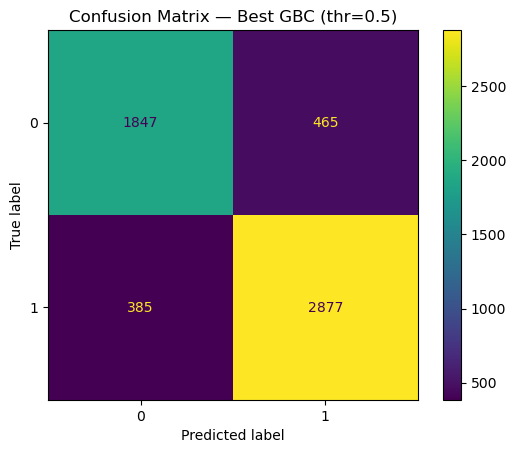

In [65]:
y_pred = best_model.predict(X_test_final)
y_proba = best_model.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("\n--- Test Metrics (threshold=0.5) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix — Best GBC (thr=0.5)")
plt.show()

## Hyperparameter Tuning 2

### Random Search

In [66]:
param_dist = {
    "gbc__n_estimators": randint(200, 600),      
    "gbc__learning_rate": uniform(0.03, 0.08),   
    "gbc__max_depth": randint(2, 5),             
    "gbc__min_samples_leaf": randint(1, 6),      
    "gbc__subsample": uniform(0.8, 0.2)         
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,                     # 30 random combinations
    scoring={"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"},
    refit="f1",                    # refit the model using the best F1
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)


### Train & Select

In [67]:
rand_search.fit(X_train_final, y_train)

print("Best Parameters:", rand_search.best_params_)
print("Best CV F1 Score:", rand_search.best_score_)

best_model = rand_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


[CV] END gbc__learning_rate=0.059963209507788995, gbc__max_depth=2, gbc__min_samples_leaf=3, gbc__n_estimators=271, gbc__subsample=0.9197316968394074; total time=   7.9s
[CV] END gbc__learning_rate=0.059963209507788995, gbc__max_depth=2, gbc__min_samples_leaf=3, gbc__n_estimators=271, gbc__subsample=0.9197316968394074; total time=   8.1s
[CV] END gbc__learning_rate=0.059963209507788995, gbc__max_depth=2, gbc__min_samples_leaf=3, gbc__n_estimators=271, gbc__subsample=0.9197316968394074; total time=   8.1s
[CV] END gbc__learning_rate=0.059963209507788995, gbc__max_depth=2, gbc__min_samples_leaf=3, gbc__n_estimators=271, gbc__subsample=0.9197316968394074; total time=   8.4s
[CV] END gbc__learning_rate=0.059963209507788995, gbc__max_depth=2, gbc__min_samples_leaf=3, gbc__n_estimators=271, gbc__subsample=0.9197316968394074; total time=   8.6s
[CV] END gbc__learning_rate=0.04248149123539492, gbc__max_depth=4, gbc__min_samples_leaf=3, gbc__n_estimators=287, gbc__subsample=0.8667417222278044; 


--- Test Metrics (threshold=0.5) ---
Accuracy : 0.8488
Precision: 0.8612
Recall   : 0.8841
F1       : 0.8725
ROC-AUC  : 0.9218

Classification Report:
               precision    recall  f1-score   support

           0     0.8301    0.7989    0.8142      2312
           1     0.8612    0.8841    0.8725      3262

    accuracy                         0.8488      5574
   macro avg     0.8456    0.8415    0.8433      5574
weighted avg     0.8483    0.8488    0.8483      5574



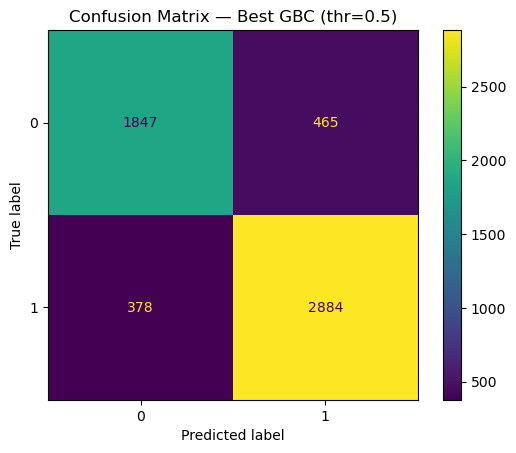

In [68]:
y_pred = best_model.predict(X_test_final)
y_proba = best_model.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("\n--- Test Metrics (threshold=0.5) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix — Best GBC (thr=0.5)")
plt.show()

## Save Model

In [69]:
model_path = "gbc_model.joblib"
joblib.dump(best_model, model_path)
print("Model saved to:", model_path)


Model saved to: gbc_model.joblib
